# Feature Engineering: Отдых и нагрузка

Физическая составляющая: плотность графика и свежесть игрока к матчу.

Для каждого игрока:
- `rest_days` - дней с предыдущего матча
- `matches_last_7d` / `matches_last_14d` - число матчей за последние 7 / 14 дней
- `games_last_7d` / `games_last_14d` - суммарное число сыгранных геймов за последние 7 / 14 дней

На уровне команды агрегируем двух игроков: среднее от обоих для непрерывных фичей.

Результат: `data/features/rest_and_load.csv`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")

df = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
df = df.sort_values("played_at").reset_index(drop=True)

def match_games(row):
    total = 0
    for s in [1, 2, 3]:
        g1 = row.get(f"set{s}_team1")
        g2 = row.get(f"set{s}_team2")
        if pd.notna(g1) and pd.notna(g2):
            total += g1 + g2
    return total

df["total_games"] = df.apply(match_games, axis=1)
print(f"Матчей: {len(df)}")

Матчей: 2549


In [2]:
def compute_rest_and_load(df):
    df = df.sort_values("played_at").reset_index(drop=True)
    # Для каждого игрока список (date, games) его предыдущих матчей
    history = defaultdict(list)

    records = []

    for _, row in df.iterrows():
        rec = {"match_id": row["match_id"]}
        d_now = row["played_at"]

        per_side = {"team_1": defaultdict(list), "team_2": defaultdict(list)}

        for pid_col, side in [("player_id_1", "team_1"), ("player_id_2", "team_1"),
                              ("player_id_3", "team_2"), ("player_id_4", "team_2")]:
            pid = row[pid_col]
            hist = history[pid]

            if hist:
                last_date = hist[-1][0]
                rest_days = (d_now - last_date).days
            else:
                rest_days = np.nan

            m_7 = sum(1 for (dd, _) in hist if (d_now - dd).days <= 7)
            m_14 = sum(1 for (dd, _) in hist if (d_now - dd).days <= 14)
            g_7 = sum(g for (dd, g) in hist if (d_now - dd).days <= 7)
            g_14 = sum(g for (dd, g) in hist if (d_now - dd).days <= 14)

            per_side[side]["rest_days"].append(rest_days)
            per_side[side]["matches_last_7d"].append(m_7)
            per_side[side]["matches_last_14d"].append(m_14)
            per_side[side]["games_last_7d"].append(g_7)
            per_side[side]["games_last_14d"].append(g_14)

        for side, prefix in [("team_1", "team1"), ("team_2", "team2")]:
            rec[f"{prefix}_rest_days"] = np.nanmean(per_side[side]["rest_days"])
            rec[f"{prefix}_matches_last_7d"] = np.mean(per_side[side]["matches_last_7d"])
            rec[f"{prefix}_matches_last_14d"] = np.mean(per_side[side]["matches_last_14d"])
            rec[f"{prefix}_games_last_7d"] = np.mean(per_side[side]["games_last_7d"])
            rec[f"{prefix}_games_last_14d"] = np.mean(per_side[side]["games_last_14d"])

        records.append(rec)

        for pid_col in ["player_id_1", "player_id_2", "player_id_3", "player_id_4"]:
            history[row[pid_col]].append((d_now, row["total_games"]))

    return pd.DataFrame(records)

In [3]:
rest = compute_rest_and_load(df)
print(f"Фич: {rest.shape[1] - 1}")
print(rest.describe())

/var/folders/3l/nhb2sbnj3lv7650ncvcld7j40000gq/T/ipykernel_1738/3901877224.py:40: RuntimeWarning: Mean of empty slice
  rec[f"{prefix}_rest_days"] = np.nanmean(per_side[side]["rest_days"])


Фич: 12
          match_id  team1_rest_days  team1_played_yesterday  \
count  2549.000000      2472.000000             2549.000000   
mean   2419.975284        20.979571                0.464104   
std    2176.372145        55.173633                0.498808   
min      34.000000         0.000000                0.000000   
25%     738.000000         1.000000                0.000000   
50%    1463.000000         3.000000                0.000000   
75%    3820.000000        14.000000                1.000000   
max    7478.000000       771.000000                1.000000   

       team1_matches_last_7d  team1_matches_last_14d  team1_games_last_7d  \
count            2549.000000             2549.000000          2549.000000   
mean                1.269910                1.998431            27.374853   
std                 1.312571                1.913042            28.554642   
min                 0.000000                0.000000             0.000000   
25%                 0.000000           

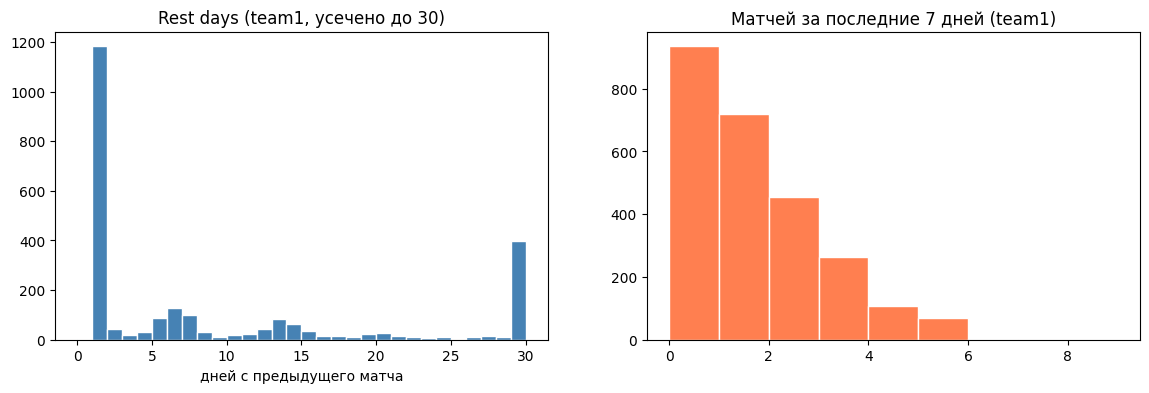

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rest["team1_rest_days"].dropna().clip(upper=30), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Rest days (team1, усечено до 30)")
axes[0].set_xlabel("дней с предыдущего матча")

axes[1].hist(rest["team1_matches_last_7d"].dropna(), bins=range(0, 10), color="coral", edgecolor="white")
axes[1].set_title("Матчей за последние 7 дней (team1)")
plt.show()

In [6]:
out_path = FEATURES / "rest_and_load.csv"
rest.to_csv(out_path, index=False)